In [16]:
import pandas as pd

df = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')
df_original = df_original[['smiles', 'mw', 'xlogp', 'polararea', 'complexity', 'rotbonds', 'heavycnt']]
df_original = df_original.rename(columns={'smiles': 'smiles_A'})

In [208]:
from rdkit import Chem

atoms_number = []
for i in df['smiles_A'].values:
    mol = Chem.MolFromSmiles(i)
    mol_with_hs = Chem.AddHs(mol)
    num_all_atoms = mol_with_hs.GetNumAtoms()

    atoms_number.append(num_all_atoms)

df['number_of_atoms'] = atoms_number

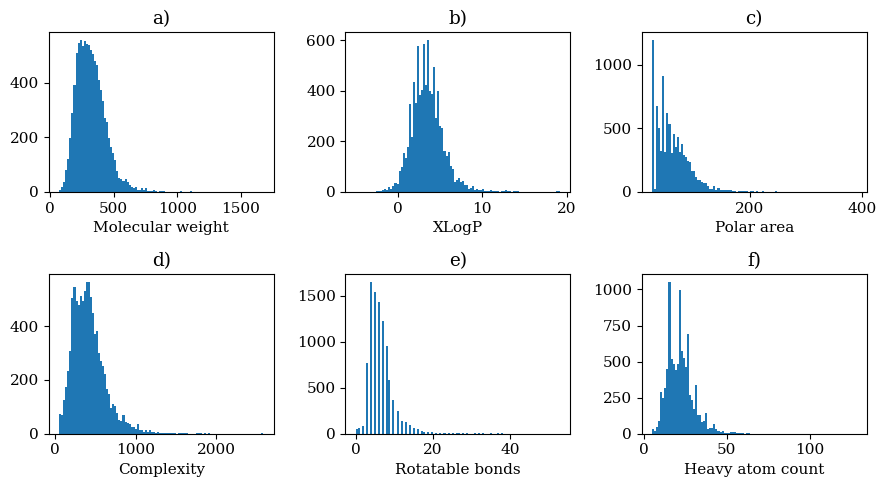

In [37]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig = plt.figure(figsize=(9,5))

plt.subplot(2,3,1)
plt.hist(df_original['mw'], bins=100)
plt.xlabel('Molecular weight')
plt.title('a)')

plt.subplot(2,3,2)
plt.hist(df_original['xlogp'], bins=100)
plt.xlabel('XLogP')
plt.title('b)')

plt.subplot(2,3,3)
plt.hist(df_original['polararea'], bins=100)
plt.xlabel('Polar area')
plt.title('c)')

plt.subplot(2,3,4)
plt.hist(df_original['complexity'], bins=100)
plt.xlabel('Complexity')
plt.title('d)')

plt.subplot(2,3,5)
plt.hist(df_original['rotbonds'], bins=100)
plt.xlabel('Rotatable bonds')
plt.title('e)')

plt.subplot(2,3,6)
plt.hist(df_original['heavycnt'], bins=100)
plt.xlabel('Heavy atom count')
plt.title('f)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_12.pdf')

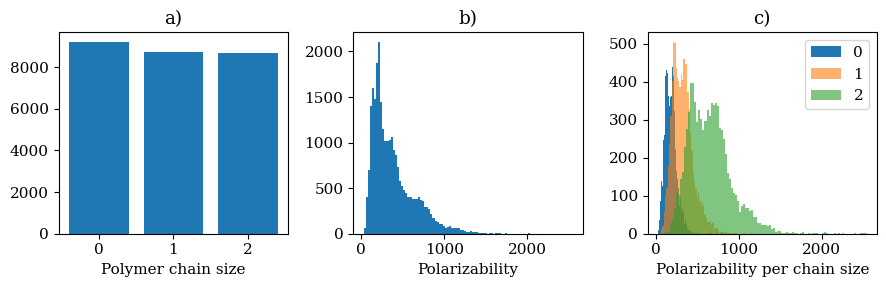

In [60]:
df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

df_chain_size = df_homopolymer.groupby('chain_size').count().reset_index()

fig = plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.bar(df_chain_size['chain_size'], df_chain_size['id_A'])
plt.xlabel('Polymer chain size')
plt.title('a)')

plt.subplot(1,3,2)
plt.hist(df_homopolymer['static_polarizability'], bins=100)
plt.xlabel('Polarizability')
plt.title('b)')

plt.subplot(1,3,3)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 0]['static_polarizability'], bins=100, alpha=1)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 1]['static_polarizability'], bins=100, alpha=0.6)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 2]['static_polarizability'], bins=100, alpha=0.6)
plt.xlabel('Polarizability per chain size')
plt.legend(['0', '1', '2'])
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_13.pdf')

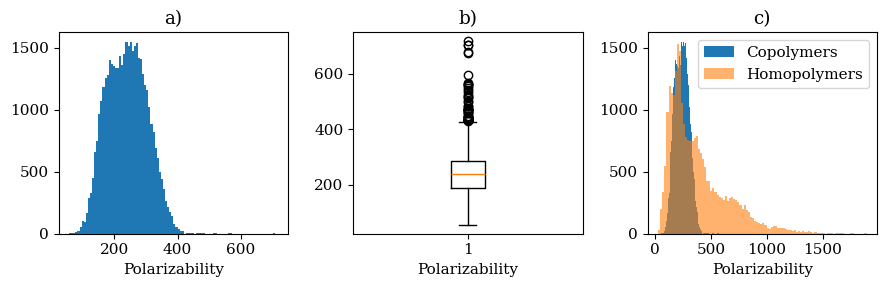

In [203]:
df_copolymer = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig = plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.hist(df_copolymer['static_polarizability'].sort_values()[:-15], bins=100)
plt.xlabel('Polarizability')
plt.title('a)')

plt.subplot(1,3,2)
plt.boxplot(df_copolymer['static_polarizability'].sort_values()[:-15])
plt.xlabel('Polarizability')
plt.title('b)')

plt.subplot(1,3,3)
plt.hist(df_copolymer['static_polarizability'].sort_values()[:-15], bins=100)
plt.hist(df_homopolymer['static_polarizability'].sort_values()[:-15], bins=100, alpha=0.6)
plt.legend(['Copolymers', 'Homopolymers'])
plt.xlabel('Polarizability')
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_14.pdf')

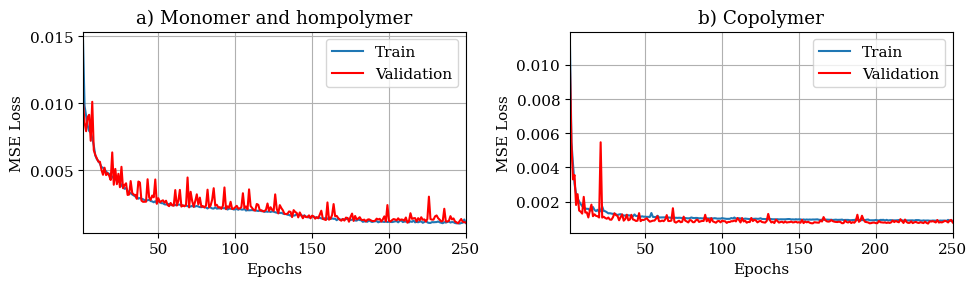

In [222]:
df_training_homopolymer = pd.read_csv('../polygraphpy/data/gnn_output/training_statistics.csv')
df_training_copolymer = pd.read_csv('../polygraphpy/data/gnn_output_copoly/training_statistics_copoly.csv')

fig = plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.plot(df_training_homopolymer['epoch']+1, df_training_homopolymer['train_loss'])
plt.plot(df_training_homopolymer['epoch']+1, df_training_homopolymer['val_loss'], 'r')
plt.grid(1)
plt.xlabel("Epochs")
plt.xlim([1, df_training_homopolymer['epoch'].max() + 1])
plt.title('a) Monomer and hompolymer')
plt.ylabel("MSE Loss")
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(df_training_copolymer['epoch']+1, df_training_copolymer['train_loss'])
plt.plot(df_training_copolymer['epoch']+1, df_training_copolymer['val_loss'], 'r')
plt.grid(1)
plt.xlabel("Epochs")
plt.xlim([1, df_training_copolymer['epoch'].max() + 1])
plt.ylabel("MSE Loss")
plt.title('b) Copolymer')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_15.pdf")

In [229]:
df_pred_homopoly = pd.read_csv(f'../polygraphpy/data/gnn_output/df_results.csv')
df_original_homopoly = pd.read_csv(f'../polygraphpy/data/gnn_output/scaled_output.csv')
df_pred_copoly = pd.read_csv(f'../polygraphpy/data/gnn_output_copoly/df_results.csv')
df_original_copoly = pd.read_csv(f'../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

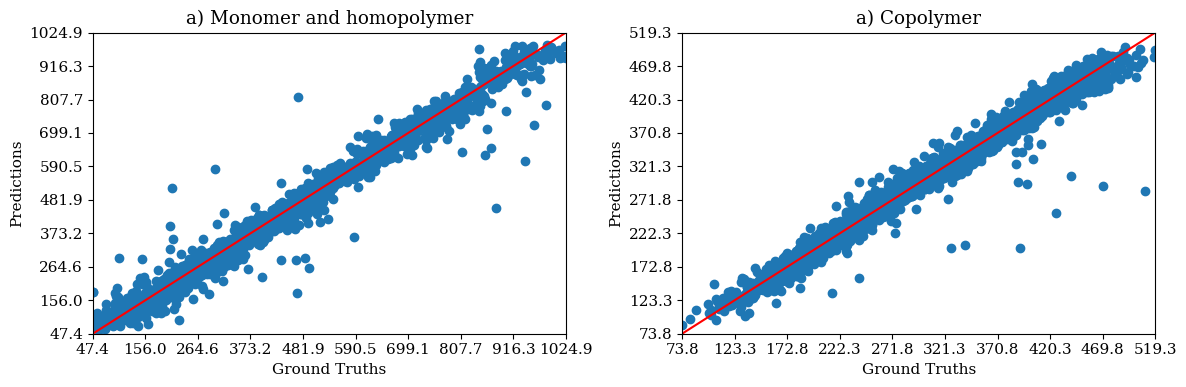

In [243]:
import numpy as np

original_min_homopoly = df_original_homopoly['static_polarizability_original'].min()
original_max_homopoly = df_original_homopoly['static_polarizability_original'].max()
original_min_copoly = df_original_copoly['static_polarizability_original'].min()
original_max_copoly = df_original_copoly['static_polarizability_original'].max()

df_pred_homopoly['y_original'] = df_pred_homopoly['y']*(original_max_homopoly + original_min_homopoly) + original_min_homopoly
df_pred_homopoly['pred_original'] = df_pred_homopoly['pred']*(original_max_homopoly + original_min_homopoly) + original_min_homopoly
df_pred_copoly['y_original'] = df_pred_copoly['y']*(original_max_copoly + original_min_copoly) + original_min_copoly
df_pred_copoly['pred_original'] = df_pred_copoly['pred']*(original_max_copoly + original_min_copoly) + original_min_copoly

fig = plt.figure(figsize=(12,4))

p1 = [df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max()]
p2 = [df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max()]
coefficients = np.polyfit(p1, p2, 1)
polynomial = np.poly1d(coefficients)
x_axis = np.linspace(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max(), 500)
y_axis = polynomial(x_axis)

plt.subplot(1,2,1)
plt.scatter(df_pred_homopoly['y_original'].values, df_pred_homopoly['pred_original'].values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max())
plt.ylim(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max())
plt.xticks( np.linspace(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max(), 10))
plt.yticks( np.linspace(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max(), 10))
plt.title('a) Monomer and homopolymer')
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")

p1 = [df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max()]
p2 = [df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max()]
coefficients = np.polyfit(p1, p2, 1)
polynomial = np.poly1d(coefficients)
x_axis = np.linspace(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max(), 500)
y_axis = polynomial(x_axis)

plt.subplot(1,2,2)
plt.scatter(df_pred_copoly['y_original'].values, df_pred_copoly['pred_original'].values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max())
plt.ylim(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max())
plt.xticks( np.linspace(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max(), 10))
plt.yticks( np.linspace(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max(), 10))
plt.title('a) Copolymer')
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_16.pdf")

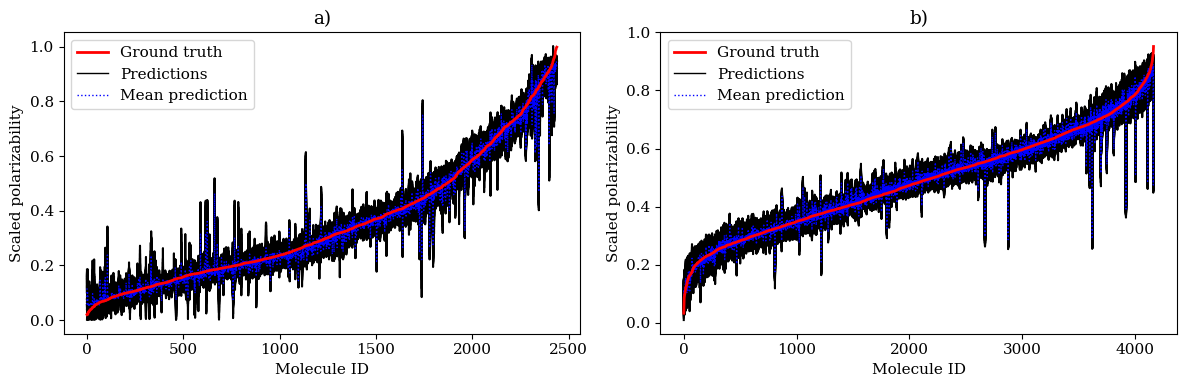

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

df_copolymer = pd.read_csv('../examples/results_uq_copolymer.csv')
df_homopolymer = pd.read_csv('../examples/results_uq_homopolymer.csv')

fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

for i in range(100):
    plt.plot(df_homopolymer.index, df_homopolymer[f'run_{i}'], color='k')

line_pred, = plt.plot(df_homopolymer.index, df_homopolymer['run_0'], 'k', linewidth=1)
line_mean, = plt.plot(df_homopolymer.index, df_homopolymer.drop(columns='y').mean(axis=1), ':b', linewidth=1)
line_gt, = plt.plot(df_homopolymer.index, df_homopolymer['y'], 'r', linewidth=2)

plt.title('a)')
plt.xlabel("Molecule ID")
plt.ylabel("Scaled polarizability")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.legend([line_gt, line_pred, line_mean], ['Ground truth', 'Predictions', 'Mean prediction'])

plt.subplot(1, 2, 2)

for i in range(100):
    plt.plot(df_copolymer.index, df_copolymer[f'run_{i}'], color='k')

line_pred, = plt.plot(df_copolymer.index, df_copolymer['run_0'], 'k', linewidth=1)
line_mean, = plt.plot(df_copolymer.index, df_copolymer.drop(columns='y').mean(axis=1), ':b', linewidth=1)
line_gt, = plt.plot(df_copolymer.index, df_copolymer['y'], 'r', linewidth=2)

plt.title('b)')
plt.xlabel("Molecule ID")
plt.ylabel("Scaled polarizability")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.legend([line_gt, line_pred, line_mean], ['Ground truth', 'Predictions', 'Mean prediction'])

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_17.pdf")

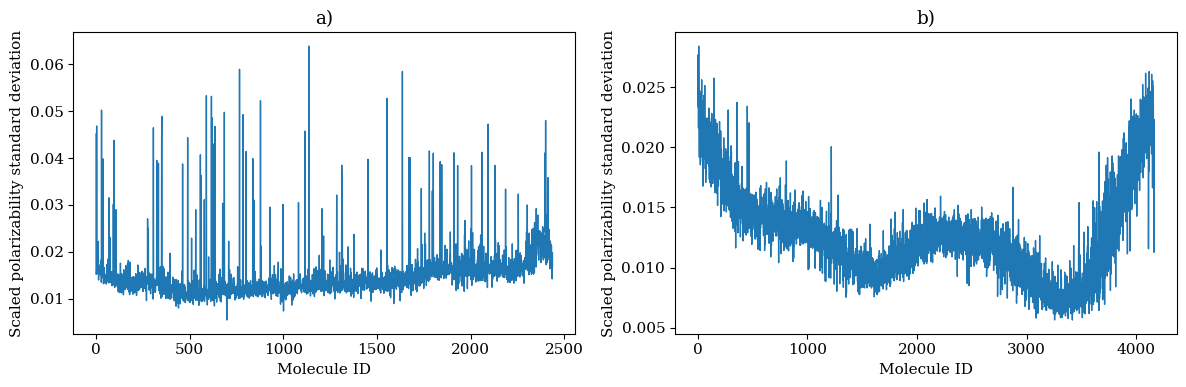

In [58]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(df_homopolymer.index, df_homopolymer.drop(columns='y').std(axis=1), linewidth=1)
plt.title('a)')
plt.xlabel("Molecule ID")
plt.ylabel("Scaled polarizability standard deviation")

plt.subplot(1, 2, 2)
plt.plot(df_copolymer.index, df_copolymer.drop(columns='y').std(axis=1), linewidth=1)
plt.title('b)')
plt.xlabel("Molecule ID")
plt.ylabel("Scaled polarizability standard deviation")

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_18.pdf")

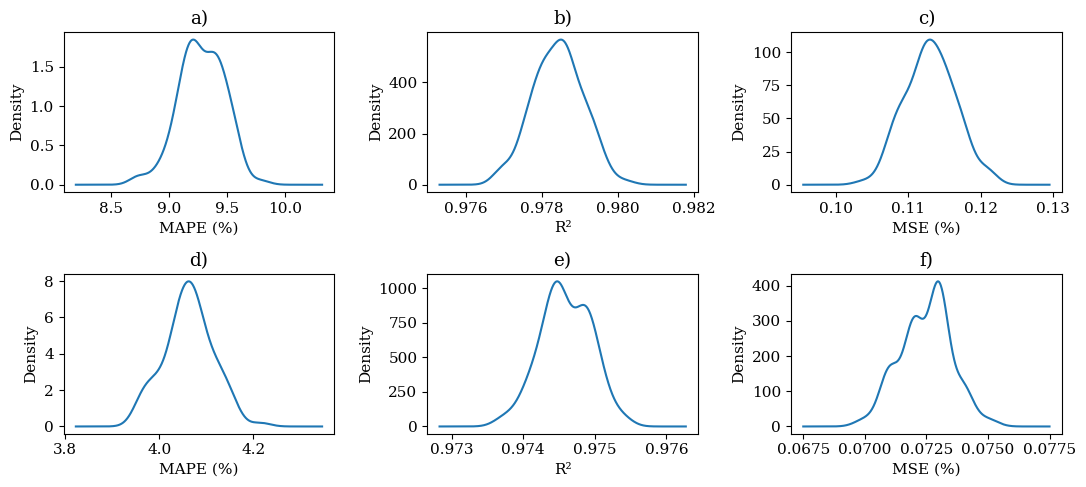

In [86]:
df_copolymer = pd.read_csv('../examples/results_uq_error_copolymer.csv')
df_homopolymer = pd.read_csv('../examples/results_uq_error_homopolymer.csv')

df_copolymer['mse'] = 100*df_copolymer['mse']
df_homopolymer['mse'] = 100*df_homopolymer['mse']

fig = plt.figure(figsize=(11,5))

plt.subplot(2,3,1)
df_homopolymer['mape'].plot.kde()
plt.xlabel('MAPE (%)')
plt.title('a)')

plt.subplot(2,3,2)
df_homopolymer['r2'].plot.kde()
plt.xlabel('R²')
plt.title('b)')

plt.subplot(2,3,3)
df_homopolymer['mse'].plot.kde()
plt.xlabel('MSE (%)')
plt.title('c)')

plt.subplot(2,3,4)
df_copolymer['mape'].plot.kde()
plt.xlabel('MAPE (%)')
plt.title('d)')

plt.subplot(2,3,5)
df_copolymer['r2'].plot.kde()
plt.xlabel('R²')
plt.title('e)')

plt.subplot(2,3,6)
df_copolymer['mse'].plot.kde()
plt.xlabel('MSE (%)')
plt.title('f)')

plt.tight_layout()
plt.show()

fig.savefig(f"../figures/Figure_19.pdf")

0.9888751113394822


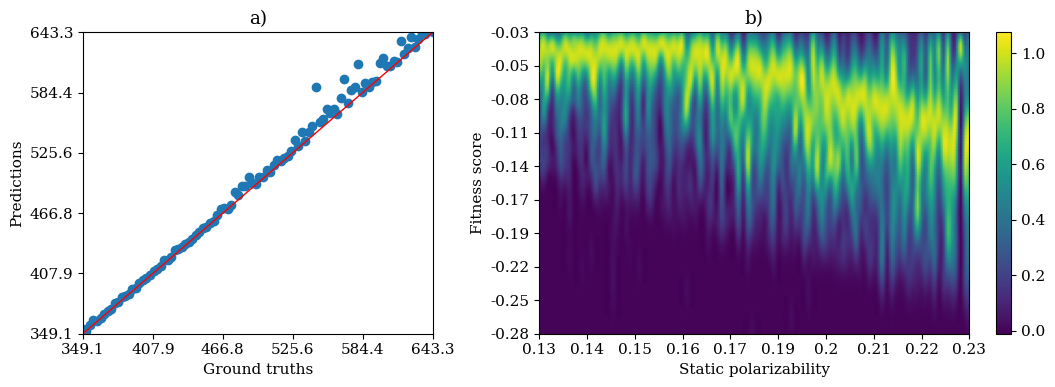

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score
from matplotlib import gridspec
from scipy.ndimage import zoom
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

df = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

scaler = MinMaxScaler()
scaler = scaler.fit(df_original['static_polarizability'].values.reshape(-1,1))

best_fitness = df.groupby('static_polarizability')['fitness'].max()
targets_sorted = df["static_polarizability"].unique()
pred = scaler.inverse_transform((targets_sorted-best_fitness).values.reshape(-1,1)).flatten()
targets_sorted = sorted(scaler.inverse_transform(targets_sorted.reshape(-1,1)).flatten())

fig = plt.figure(figsize=(11, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 2]) 
a0 = plt.subplot(gs[0])
a1 = plt.subplot(gs[1])

targets_sorted = np.array(targets_sorted)

a0.scatter(targets_sorted, pred)
a0.plot([targets_sorted.min(), targets_sorted.max()], [targets_sorted.min(), targets_sorted.max()], "r", linewidth=1)
a0.set_xlim([targets_sorted.min(), targets_sorted.max()])
a0.set_ylim([targets_sorted.min(), targets_sorted.max()])
a0.set_xticks(np.linspace(targets_sorted.min(), targets_sorted.max(), 6))
a0.set_yticks(np.linspace(targets_sorted.min(), targets_sorted.max(), 6))
a0.set_xlabel("Ground truths")
a0.set_ylabel("Predictions")
a0.set_title("a)")

print(r2_score(targets_sorted, pred))

groups = df.groupby('static_polarizability')
polar_values = sorted(groups.groups.keys())
n_molecules = 100
fitness_values = np.linspace(df['fitness'].min(), df['fitness'].max(), n_molecules)
kde_matrix = np.zeros((n_molecules, len(polar_values)))

for i, polar in enumerate(polar_values):
    fitness = groups.get_group(polar)['fitness'].values
    kde = gaussian_kde(fitness, bw_method=0.3)
    kde_values = kde(fitness_values)
    kde_matrix[:, i] = kde_values / kde_values.max()  # Normalize for visualization

n = 200
zoom_factor = n / kde_matrix.shape[0] 
interpolated_matrix = zoom(kde_matrix, zoom=zoom_factor, order=3) 

a1.pcolormesh(np.array(interpolated_matrix), shading='gouraud')
a1.set_xlabel('Static polarizability')
a1.set_ylabel('Fitness score')
a1.set_title('b)')
n_x = min(len(interpolated_matrix), 10)
n_y = min(len(interpolated_matrix), 10)
fitness_values = np.linspace(df['fitness'].min(), df['fitness'].max(), n)
polar_values = np.linspace(min(polar_values), max(polar_values), n)
a1.set_xticks(np.linspace(0, len(interpolated_matrix)-1, n_x), np.round(polar_values, 2)[::len(polar_values)//n_x])
a1.set_yticks(np.linspace(0, len(interpolated_matrix)-1, n_y), np.round(fitness_values, 2)[::len(fitness_values)//n_y])
PCM=a1.get_children()[0]
plt.colorbar(PCM, ax=a1) 

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_21.pdf", transparent=False)

In [55]:
df_original= pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original[df_original['chain_size'] == 0].reset_index(drop=True)

df_aux = df.drop_duplicates(subset='smiles')

1 - len(df_aux[df_aux['smiles'].isin(df_original['smiles_A'])])/len(df_aux)

0.9995604395604396